# Specify priors and fix parameters

Every HSSM model accepts custom priors — and fixed (non-sampled) parameter values — through the same small set of patterns. This page is the reference walkthrough for all of them: the `include` argument (dictionaries and `hssm.Param`), `hssm.Prior`, bounds, the shortcut keyword syntax, and coefficient priors in regressions.

If you have not fit a model yet, start with the [Quickstart](https://lnccbrown.github.io/HSSM/getting_started/getting_started/).

## Run this how-to

<a href="https://colab.research.google.com/github/lnccbrown/HSSM/blob/main/docs/how_to/specify_priors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open this notebook in Google Colab"></a>

On Colab, uncomment and run the installation cell below once, then restart the runtime. For local setup, GPU extras, and troubleshooting see the [Installation guide](https://lnccbrown.github.io/HSSM/getting_started/installation/).


In [1]:
# %pip install hssm

## Setup

We reuse the quickstart's simulated DDM dataset.

In [2]:
import arviz as az
import numpy as np

import hssm

%matplotlib inline

v_true, a_true, z_true, t_true = [0.5, 1.5, 0.5, 0.5]
dataset = hssm.simulate_data(
    model="ddm",
    theta=[v_true, a_true, z_true, t_true],
    size=1000,
)

dataset

,rt,response
0,2.738526,1.0
1,2.379609,1.0
2,1.780142,1.0
3,1.955865,-1.0
4,1.934673,1.0
...,...,...
995,1.741570,1.0
996,1.147650,1.0
997,1.571325,-1.0
998,1.486842,1.0


## The non-regression case

Next, let's take a look at how to specify priors in the non-regression case. In HSSM, parameter specification can be done in two ways:

1. through the `include` parameter, or
2. through a shortcut

### Through the `include` parameter

The `include` parameter accepts a list of dictionaries or `hssm.Param` objects. Both dictionaries and `hssm.Param` objects are equivalent, since the content of the dictionary will be passed as parameters to the `hssm.Param` class during model creation, so it is more of a matter of preference. We recommend the `hssm.Param` object because some IDEs will be able to provide prompts for possible options of parameters. In the non-regression case, each dictionary typically looks like this:

```python
{
    "name": "v",
    "prior": {
        "name": "Uniform",
        "lower": -5.0,
        "upper": 5.0,
    },
    "bounds": (-10.0, 10.0)
}
```

This is equivalent to writing:

```python
hssm.Param(
    "v",
    prior=dict(name="Uniform", upper=-5.0, lower=5.0),
    bounds=(-10.0, 10.0)
)
```

The `name` field corresponds to the name of the parameter being specified.

The `prior` field specifies the distribution of the prior. There are two ways to achieve this:

1. A dictionary with the `name` of the distribution (**typically captalized**) and the parameters of the distribution that you would typically set if you were specifying a distribution in `PyMC`. For example, if you would like to specify `pm.Normal(mu=0.0, sigma=1.0)` as the prior, then in `HSSM`, this prior dictionary would be:

```python
{
    "name": "Normal", ## Note it is capitalized
    "mu": 0.0,
    "sigma": 1.0,
}
```

or, using the `dict` constructor:

```python
dict(name="Normal", mu=0.0, sigma=1.0)
```

2. A `hssm.Prior` object. This is exactly how you would specify priors using `bambi` (In fact, `hssm.Prior` is a subclass of `bmb.Prior` and for the most part can be used interchangeably with `bmb.Prior`). To specify the same normal prior as above, you would write:

```python
hssm.Prior("Normal", mu=0.0, sigma=1.0)
```

The `bounds` field accepts a tuple of floats, indicating the lower and upper bounds for the parameter.

**Fixing parameters**: sometimes you might want to fix the values of a parameter. You can easily do so by specifying that value to the `prior` field of the dictionary. In the following example, the paramter `v` is fixed to `0.5`.

```python
{
    "name": "v",
    "prior": 0.5,
}
```

Now let's make this concrete with an example:

In [3]:
# A Normal prior for `v` without explicit bounds
param_v = {
    "name": "v",
    "prior": {
        "name": "Normal",
        "mu": 0.0,
        "sigma": 2.0,
    },
}

# A Uniform prior for `a`. Using the `dict` function
param_a = hssm.Param(
    "a",
    prior=dict(
        name="Uniform",
        lower=0.01,
        upper=5,
    ),
    bounds=(0, np.inf),
)

# A Uniform prior for `z` over (0, 1) set using hssm.Prior.
# bounds are not set, existing default bounds will be used
param_z = {"name": "z", "prior": hssm.Prior("Uniform", lower=0.0, upper=1.0)}

# A fixed value for t
param_t = {"name": "t", "prior": 0.5}

example_ddm_model = hssm.HSSM(
    data=dataset,
    model="ddm",
    include=[
        param_v,
        param_a,
        param_z,
        param_t,
    ],
)

example_ddm_model

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1000

Parameters:

v:
    Prior: Normal(mu: 0.0, sigma: 2.0)
    Explicit bounds: (-inf, inf)

a:
    Prior: Uniform(lower: 0.01, upper: 5.0)
    Explicit bounds: (0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: 0.5
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

In [4]:
example_ddm_model.sample()

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, z, v]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           v        (chain, draw) float64 32kB 0.5977 0.5554 0.5565 ... 0.5036 0.5587
│           a        (chain, draw) float64 32kB 1.529 1.478 1.498 ... 1.497 1.506 1.5
│           z        (chain, draw) float64 32kB 0.4791 0.4979 0.485 ... 0.4907 0.5159
│       Attributes:
│           created_at:                  2026-08-12T22:48:57.855420+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           inference_library:           pymc
│           inference_library_version:   6.3.0
│           sample_dims:                 ['chain', 'draw']
│           sampling_time:               7.060505151748657
│           tuning_steps:                1000
│           modeling_interface:          bambi
│           modeling_interface_version:  0.20.0
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           energy                 (chain, draw) float64 32kB 1.974e+03 ... 1.976e+03
│           energy_error           (chain, draw) float64 32kB -0.1264 ... -0.1279
│           process_time_diff      (chain, draw) float64 32kB 0.001743 ... 0.001736
│           diverging              (chain, draw) bool 4kB False False ... False False
│           ...                     ...
│           step_size_bar          (chain, draw) float64 32kB 0.7508 0.7508 ... 0.7819
│           max_energy_error       (chain, draw) float64 32kB -0.2441 ... -0.6603
│           divergences            (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
│           perf_counter_start     (chain, draw) float64 32kB 2.255e+05 ... 2.255e+05
│           index_in_trajectory    (chain, draw) int64 32kB 1 2 2 2 -2 -1 ... 2 2 2 5 2
│           step_size              (chain, draw) float64 32kB 0.7543 0.7543 ... 0.7689
│       Attributes:
│           created_at:                  2026-08-12T22:48:57.860696+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           inference_library:           pymc
│           inference_library_version:   6.3.0
│           sample_dims:                 ['chain', 'draw']
│           sampling_time:               7.060505151748657
│           tuning_steps:                1000
│           modeling_interface:          bambi
│           modeling_interface_version:  0.20.0
├── Group: /observed_data
│       Dimensions:                  (__obs__: 1000, rt,response_extra_dim_0: 2)
│       Coordinates:
│         * __obs__                  (__obs__) int64 8kB 0 1 2 3 4 ... 996 997 998 999
│         * rt,response_extra_dim_0  (rt,response_extra_dim_0) int64 16B 0 1
│       Data variables:
│           rt,response              (__obs__, rt,response_extra_dim_0) float64 16kB ...
│       Attributes:
│           created_at:                  2026-08-12T22:48:57.862284+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.3.0
│           creation_library_language:   Python
│           inference_library:           pymc
│           inference_library_version:   6.3.0
│           sample_dims:                 []
│           modeling_interface:          bambi
│           modeling_interface_version:  0.20.0
└── Group: /log_likelihood
        Dimensions:      (chain: 4, draw:

In [5]:
az.summary(example_ddm_model.traces)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v,0.571,0.0338,0.52,0.62,2416,2678,1.00,0.00069,0.00048
a,1.5013,0.0229,1.5,1.5,2943,2533,1.00,0.00042,0.0003
z,0.4901,0.012,0.47,0.51,2230,2436,1.00,0.00025,0.00018


### Specifying priors using the shortcut

HSSM also supports a syntax very similar to `PyMC`: You can directly specify priors by passing the prior to the name of the parameter in `hssm.HSSM`. This is convenient if the prior is simple. Below is an example almost equivalent to the above example:

In [6]:
# All ways to specify priors mentioned above are supported in the shortcut syntax
shortcut_ddm_model = hssm.HSSM(
    data=dataset,
    model="ddm",
    v={"name": "Normal", "mu": 0.0, "sigma": 2.0},
    a=dict(name="Uniform", lower=0.01, upper=5),
    z=hssm.Prior("Uniform", lower=0.01, upper=1.0),
    t=0.5,
)

shortcut_ddm_model

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1000

Parameters:

v:
    Prior: Normal(mu: 0.0, sigma: 2.0)
    Explicit bounds: (-inf, inf)

a:
    Prior: Uniform(lower: 0.01, upper: 5.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.01, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: 0.5
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

**Note that the shortcut syntax also supports specifying bounds. It will be more polished in a future update. We will skip this step for now.**

## The regression case

Built on top of `bambi`, HSSM uses an `lmer`-like syntax that makes it extremely straight-forward to specify regressions.

Parameters that are targets of regressions are also specified using dictionaries in `include`. Below is an example for such dictionaries.

```python
{
    "name": "v",
    "formula": "v ~ 1 + x + y",
    "prior": {
        # All ways to specify priors in the non-regression case
        # work the same way here.
        "Intercept": {"name": "Uniform", "lower": -10.0, "upper": 10.0},
        "x": dict(name="Normal", mu=0, sigma=1),
        "y": hssm.Prior("HalfNormal", sigma=0.5),
        "z": 1.0
    }
    "link": "identity",
    "bounds": (-10.0, 10.0)
}
```

We see that in the regression case, `name` and `bounds` are specified the exact same way as in the non-regression case. The regression formula is specified in a way that's very similar to the `lmer` package in R. Users that have experience with R formulas should be very familar with this syntax. In this case, the formula means that the parameter `v` is regressed on variables `x` and `y`, which can be found in the dataframe passed to `hssm.HSSM`. The `1` explicitly specifies an intercept for the regression.

In addition to the `formula`, users typically need to specify priors for the regression coefficients. This is done in the `prior` field of the dictionary. Instead of specifying priors for the parameter, the priors are now specified for the corresponding regression coefficients. If not specified, HSSM will use default priors generated in Bambi.

Users might also want to specify a `link` function for generalized linear models. If left unspecified, the `identity` link function will be used.

Now let's see an example of a regression:

In [7]:
# Generate simulated data

intercept = 1.5
x = np.random.uniform(-5.0, 5.0, size=1000)
y = np.random.uniform(-5.0, 5.0, size=1000)

v = intercept + 0.8 * x + 0.3 * y

In [8]:
true_values = np.column_stack([v, np.repeat([[1.5, 0.5, 0.5]], axis=0, repeats=1000)])
true_values.shape

(1000, 4)

In [9]:
dataset_reg_v = hssm.simulate_data(
    model="ddm",
    theta=true_values,
    size=1,  # Generate one data point for each of the 1000 set of true values
)

dataset_reg_v["x"] = x
dataset_reg_v["y"] = y

dataset_reg_v

,rt,response,x,y
0,2.638611,-1.0,-0.340989,-4.840536
1,0.922815,1.0,2.052331,-4.828024
2,2.075011,-1.0,-3.574361,2.599690
3,3.206385,1.0,-0.338693,0.398921
4,2.437208,-1.0,-1.220605,-4.044089
...,...,...,...,...
995,2.609189,-1.0,-2.462546,0.113518
996,1.458471,1.0,-0.867655,-2.398150
997,1.162385,-1.0,-4.322686,-1.255193
998,1.447900,1.0,-2.680532,1.878721


In [10]:
model_reg_v = hssm.HSSM(
    data=dataset_reg_v,
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + x + y",
            "prior": {
                "Intercept": {"name": "Uniform", "lower": -0.001, "upper": 0.5},
                "x": dict(name="Uniform", lower=0.0, upper=1.0),
                "y": hssm.Prior("Uniform", lower=0.0, upper=1.0),
            },
            "link": "identity",
        }
    ],
)
model_reg_v

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 1000

Parameters:

v:
    Formula: v ~ 1 + x + y
    Priors:
        v_Intercept ~ Uniform(lower: -0.001, upper: 0.5)
        v_x ~ Uniform(lower: 0.0, upper: 1.0)
        v_y ~ Uniform(lower: 0.0, upper: 1.0)
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

In [11]:
model_reg_v.initvals

{'a': array(1.5),
 'z': array(0.5),
 't': array(0.025),
 'v_Intercept': array(0.),
 'v_x': array(0.5),
 'v_y': array(0.5)}

In [12]:
# Uncomment to see model graph if you have graphviz installed
# model_reg_v.graph()

In [13]:
trace_reg_v = model_reg_v.sample()

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [a, z, t, v_Intercept, v_x, v_y]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


In [14]:
# Looks like parameter recovery was successful
az.summary(model_reg_v.traces)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z,0.618,0.0085,0.6,0.63,4178,3101,1.00,0.00013,9.4e-05
v_y,0.2613,0.0144,0.24,0.28,4411,3402,1.00,0.00022,0.00016
t,0.5487,0.0075,0.54,0.56,3809,2866,1.00,0.00012,8.6e-05
a,1.269,0.0295,1.2,1.3,3330,2744,1.00,0.00051,0.00036
v_x,0.6173,0.0183,0.59,0.65,3500,2952,1.00,0.00031,0.00023
v_Intercept,0.5023,0.004,0.5,0.51,4827,3959,1.00,5.8e-05,5.7e-05


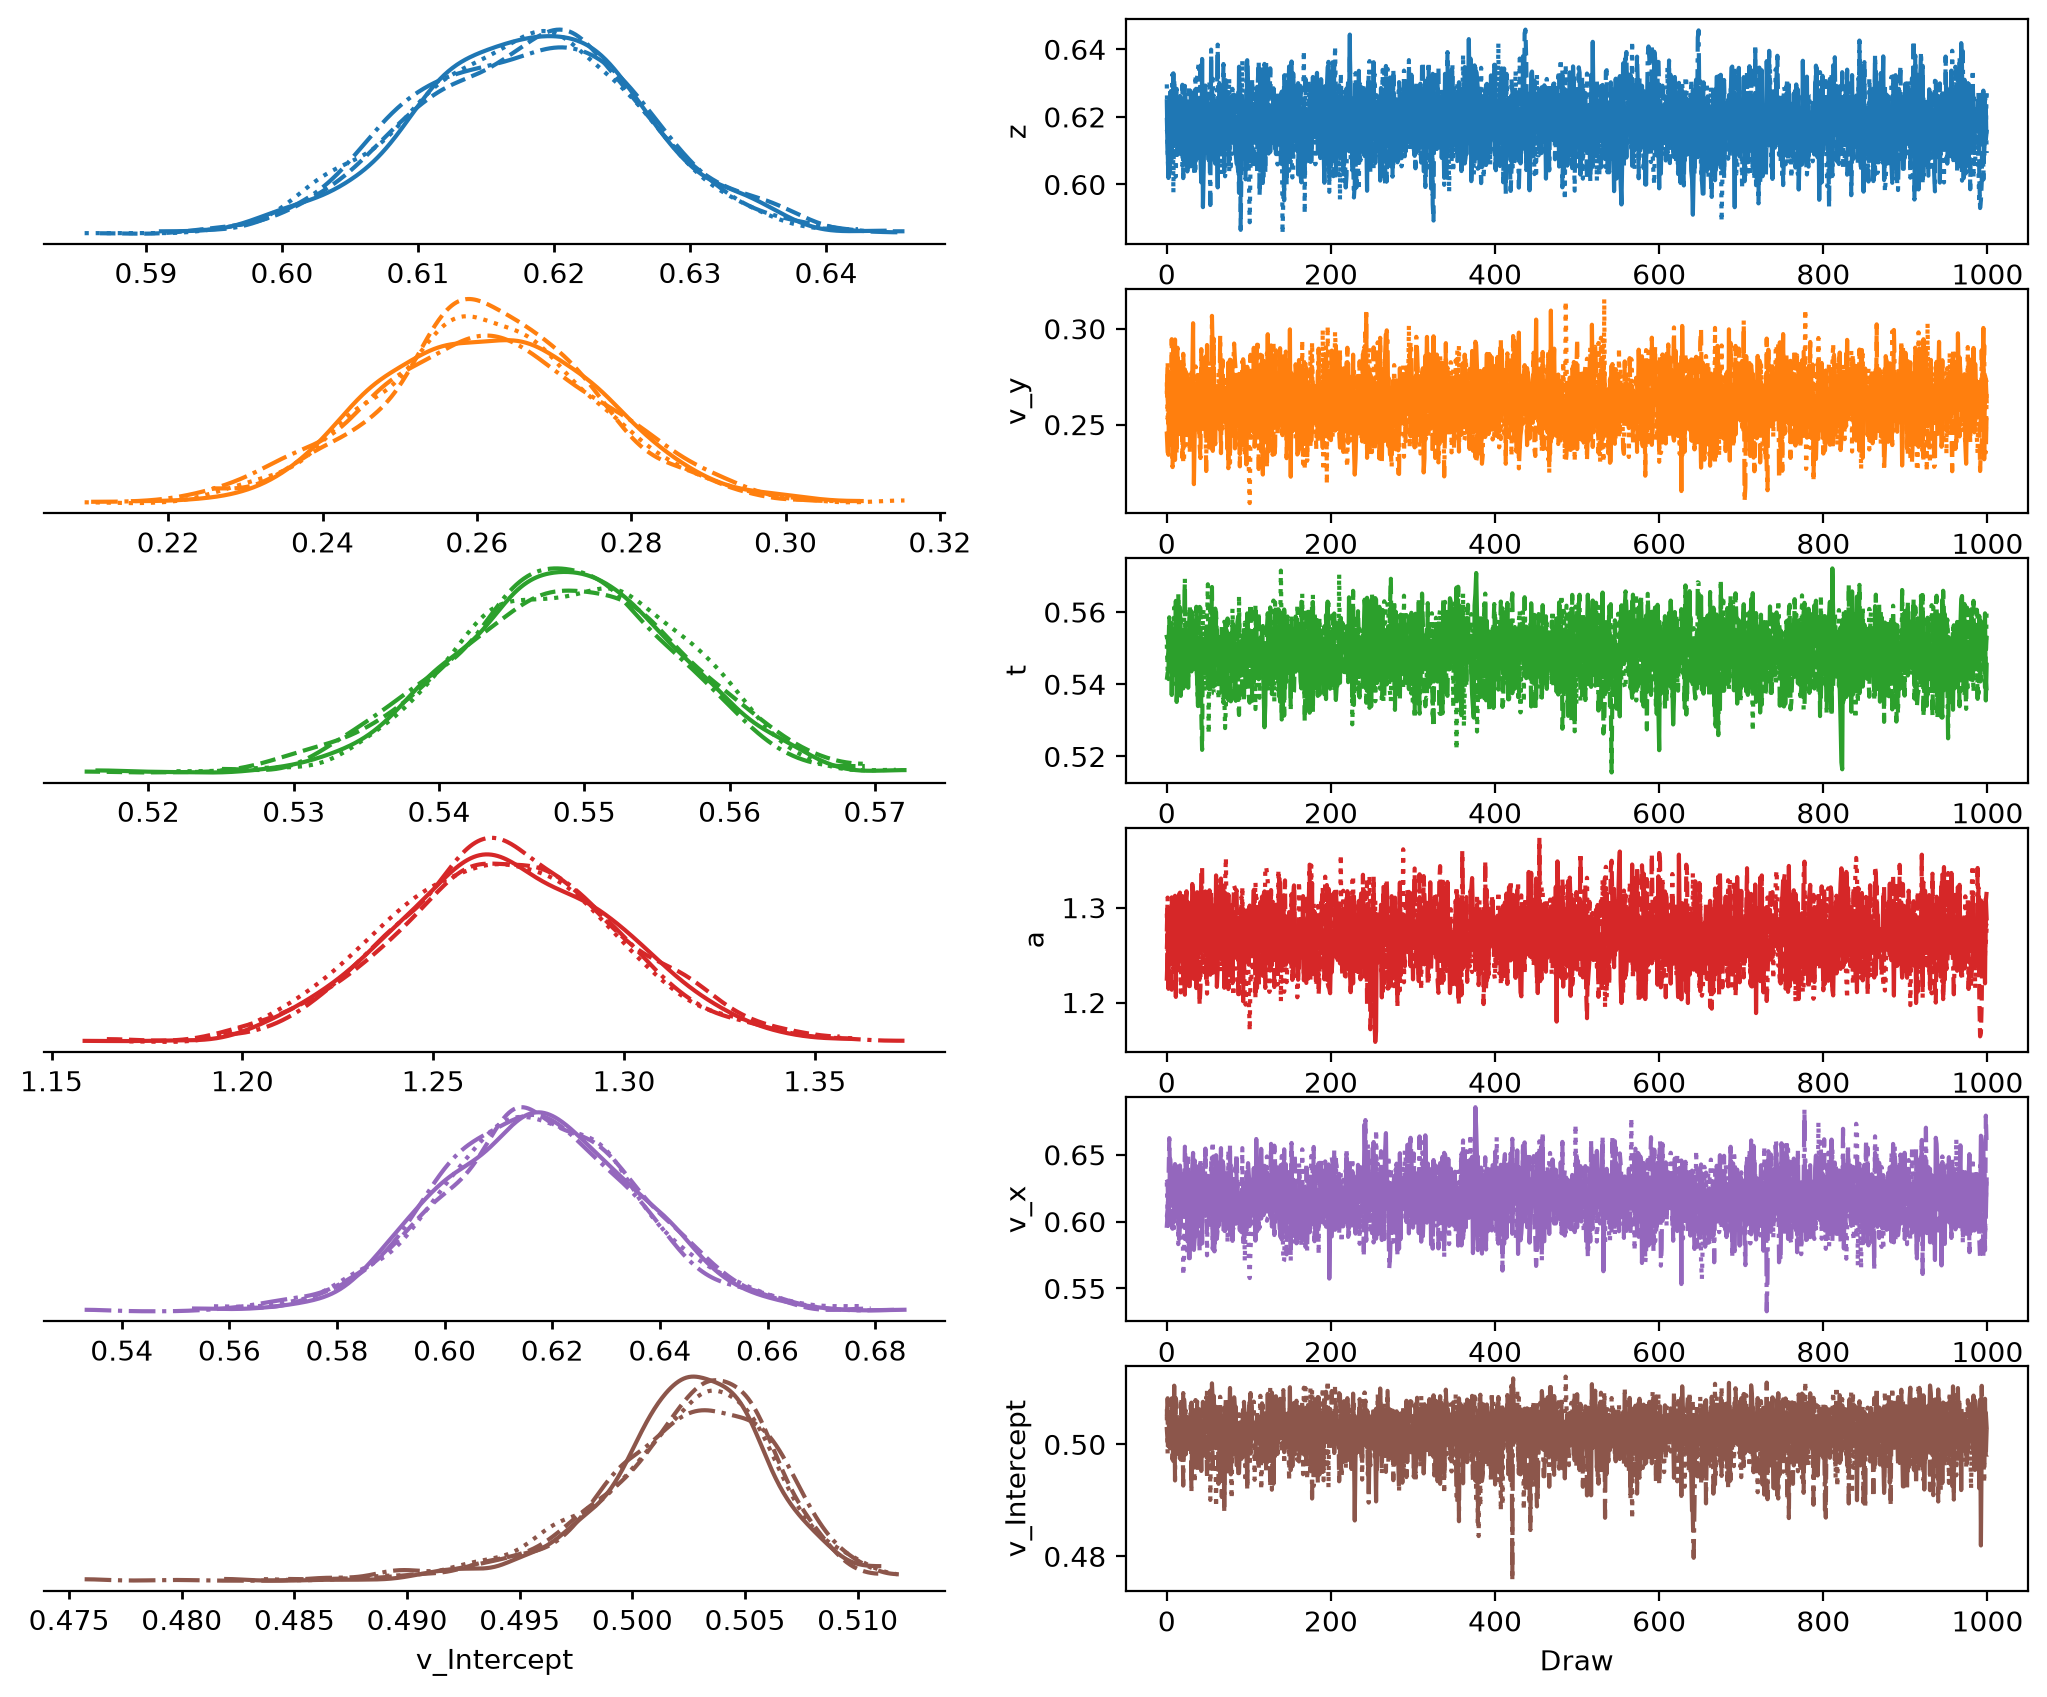

In [15]:
az.plot_trace_dist(model_reg_v.traces);

## See also

- [`hssm.Prior` API reference](https://lnccbrown.github.io/HSSM/api/prior/) and [`hssm.Param` API reference](https://lnccbrown.github.io/HSSM/api/param/)
- [Setting initial values](https://lnccbrown.github.io/HSSM/tutorials/initial_values/) — when sampling needs a hand beyond priors
- [The HSSM tutorial: scenic route](https://lnccbrown.github.io/HSSM/tutorials/main_tutorial_scenic_route/), which motivates these choices in a comprehensive modeling context

## Prior and link settings for hierarchical models

`bambi` is not designed with HSSM in mind: where priors for regression parameters are not explicitly defined, bambi's defaults are sometimes not optimal, and `"identity"` link functions tend not to work well for parameters that are not defined on the whole real line. HSSM therefore provides two safeguard settings, most useful for hierarchical models (the examples below use the `cavanagh_theta` dataset with a `global_formula` that gives every parameter a participant-level random intercept).

In [16]:
cav_data = hssm.load_data("cavanagh_theta")

### `prior_settings`

Currently we provide a `"safe"` strategy that uses HSSM default priors, which is turned on by default for parameters that are targets of regressions. One can compare the two models below, with `safe` strategy turned on and off:

In [17]:
model_safe = hssm.HSSM(
    data=cav_data,
    global_formula="y ~ 1 + (1|participant_id)",
    prior_settings="safe",
    loglik_kind="approx_differentiable",
)
model_safe

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 3988

Parameters:

v:
    Formula: v ~ 1 + (1|participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-3.0, 3.0)

a:
    Formula: a ~ 1 + (1|participant_id)
    Priors:
        a_Intercept ~ Normal(mu: 1.4, sigma: 0.25)
        a_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (0.3, 2.5)

z:
    Formula: z ~ 1 + (1|participant_id)
    Priors:
        z_Intercept ~ Normal(mu: 0.5, sigma: 0.25)
        z_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1 + (1|participant_id)
    Priors:
        t_Intercept ~ Normal(mu: 1.0, sigma: 0.25)
        t_1|partic

In [18]:
model_safe_off = hssm.HSSM(
    data=cav_data,
    global_formula="y ~ 1 + (1|participant_id)",
    prior_settings=None,
    loglik_kind="approx_differentiable",
)
model_safe_off

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 3988

Parameters:

v:
    Formula: v ~ 1 + (1|participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 2.5)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
    Link: identity
    Explicit bounds: (-3.0, 3.0)

a:
    Formula: a ~ 1 + (1|participant_id)
    Priors:
        a_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
        a_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))
    Link: identity
    Explicit bounds: (0.3, 2.5)

z:
    Formula: z ~ 1 + (1|participant_id)
    Priors:
        z_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
        z_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1 + (1|participant_id)
    Priors:
        t_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
        t_1|participant_id ~ Normal(mu: 0.0, s

### `link_settings`

We also provide a `link_settings` switch, which changes default link functions for parameters according to their explicit bounds. See the model below with `link_settings` set to `"log_logit"`:

In [19]:
model_log_logit = hssm.HSSM(
    data=cav_data,
    global_formula="y ~ 1 + (1|participant_id)",
    prior_settings=None,
    link_settings="log_logit",
)
model_log_logit

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 3988

Parameters:

v:
    Formula: v ~ 1 + (1|participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 2.5)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
    Link: identity
    Explicit bounds: (-inf, inf)
 (ignored due to link function)
a:
    Formula: a ~ 1 + (1|participant_id)
    Priors:
        a_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
        a_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))
    Link: log
    Explicit bounds: (0.0, inf)
 (ignored due to link function)
z:
    Formula: z ~ 1 + (1|participant_id)
    Priors:
        z_Intercept ~ Normal(mu: 0.0, sigma: 1.0)
        z_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))
    Link: Generalized logit link function with bounds (0.0, 1.0)
    Explicit bounds: (0.0, 1.0)
 (ignored due to link function)
t:
    Formula: t ~ 1 + (1|p

### Mixing strategies:

It is possible to turn on both `prior_settings` and `link_settings`:

In [20]:
model_safe_loglogit = hssm.HSSM(
    data=cav_data,
    global_formula="y ~ 1 + (1|participant_id)",
    prior_settings="safe",
    link_settings="log_logit",
)
model_safe_loglogit

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 3988

Parameters:

v:
    Formula: v ~ 1 + (1|participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)
 (ignored due to link function)
a:
    Formula: a ~ 1 + (1|participant_id)
    Priors:
        a_Intercept ~ Normal(mu: 0.0, sigma: 0.25)
        a_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: log
    Explicit bounds: (0.0, inf)
 (ignored due to link function)
z:
    Formula: z ~ 1 + (1|participant_id)
    Priors:
        z_Intercept ~ Normal(mu: 0.0, sigma: 0.25)
        z_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: Generalized logit link function with bounds (0.0, 1.0)
    Explicit bounds: (0.0, 1.0)
 (ignored due to link function)
t